# Part 11c: Missing Observations in HMMs

Part 7 introduced Hidden Markov Models in `dynestyx`, and Parts 11 / 11b discussed missing observations for continuous latent-state models.

This tutorial does the HMM version of that story: we keep a **finite latent state space**, but vary the **observation family** and ask what kinds of missingness we can treat exactly.

The key point is that missingness in an HMM changes only the **observation update**, not the forward recursion itself. Once we can evaluate

$$
\log p(y_{t,\mathrm{obs}} \mid z_t),
$$

for each latent state $z_t$, the usual forward algorithm continues unchanged.


## 1. Missing-data cases in a generic HMM

Consider a generic HMM

$$
z_0 \sim p(z_0 \mid 	\theta),
\qquad
z_t \sim p(z_t \mid z_{t-1}, 	\theta),
\qquad
y_t \sim p(y_t \mid z_t, 	\theta).
$$

With missing observations, there are two main cases.

1. **Full-row missingness:** the entire observation at time $t$ is absent.
   In an HMM this is the easiest case: we simply neutralize the observation term, so the filter performs a pure prediction step at that time.

2. **Partial missingness:** only some coordinates of $y_t$ are observed.
   This requires an exact way to replace
   $\log p(y_t \mid z_t)$ by
   $\log p(y_{t,\mathrm{obs}} \mid z_t)$.

The current HMM missingness support in `dynestyx` falls into three observation-family buckets:

| Observation family | Full-row missing? | Partial missing? | Why |
|---|---:|---:|---|
| `MultivariateNormal` | Yes | Yes | We can evaluate the exact Gaussian marginal over the observed coordinates. |
| `Independent(..., 1)` | Yes | Yes | The log-probability factorizes across coordinates, so we sum only the observed pieces. |
| Correlated joint discrete families | Yes | No, not generically | There is no built-in coordinate-wise marginalizer for an arbitrary correlated discrete observation family. |

Below we work through the two fully built-in cases with the **same latent Markov chain** and vary only the observation family:

1. 2D multivariate Gaussian observations
2. Two independent binary categorical observations

After that, we briefly summarize what an advanced third example with a correlated discrete pair would require.

In both worked examples we infer the transition matrix $A$ and compare the filtered latent reconstruction against the true hidden states.


In [1]:
import arviz as az
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

import dynestyx as dsx
from dynestyx import DiscreteTimeSimulator, DynamicalModel, Filter
from dynestyx.inference.filter_configs import HMMConfig

jax.config.update("jax_enable_x64", True)
az.style.use("arviz-white")


In [2]:
# Notebook-only utilities: the examples below still use the standard Dynestyx pattern
# `model -> dsx.sample -> Filter(HMMConfig()) -> MCMC / Predictive`.
# The helpers in this cell are just light setup and plotting wrappers.

TRUE_A = jnp.array([[0.92, 0.08], [0.12, 0.88]])
OBS_TIMES = jnp.arange(100.0)
N_WARMUP = 2500
N_SAMPLES = 2500
GLOBAL_SEED = 0
MASTER_KEY = jr.PRNGKey(GLOBAL_SEED)
(
    DATA_KEY_MVN,
    FIT_KEY_MVN,
    RECON_KEY_MVN,
    DATA_KEY_CAT,
    FIT_KEY_CAT,
    RECON_KEY_CAT,
) = jr.split(MASTER_KEY, 6)

STATE_COLORS = ["#f3dfb6", "#d6e7d4"]
MISSING_COLOR = "#6c757d"


def make_hmm_model(observation_model):
    def model(A=None, obs_times=None, obs_values=None, predict_times=None):
        A = numpyro.sample(
            "A",
            dist.Dirichlet(jnp.ones(2)).expand([2]).to_event(1),
            obs=A,
        )

        def state_evolution(x, u, t_now, t_next):
            return dist.Categorical(probs=A[x])

        dynamics = DynamicalModel(
            initial_condition=dist.Categorical(probs=jnp.array([0.5, 0.5])),
            state_evolution=state_evolution,
            observation_model=observation_model,
            control_dim=0,
        )

        return dsx.sample(
            "f",
            dynamics,
            obs_times=obs_times,
            obs_values=obs_values,
            predict_times=predict_times,
        )

    return model


def simulate_hmm_dataset(model, *, key, true_A=TRUE_A, obs_times=OBS_TIMES):
    predictive = Predictive(model, num_samples=1, exclude_deterministic=False)
    with DiscreteTimeSimulator():
        synthetic = predictive(key, A=true_A, predict_times=obs_times)

    states_true = jnp.asarray(synthetic["f_states"])[0, 0, :, 0]
    observations = jnp.asarray(synthetic["f_observations"])[0, 0]
    return states_true, observations


def infer_hmm(model, obs_times, obs_values, *, fit_key, recon_key, num_warmup=N_WARMUP, num_samples=N_SAMPLES):
    with Filter(filter_config=HMMConfig(record_filtered=True)):
        mcmc = MCMC(
            NUTS(model),
            num_warmup=num_warmup,
            num_samples=num_samples,
            progress_bar=False,
        )
        mcmc.run(fit_key, obs_times=obs_times, obs_values=obs_values)
        posterior = mcmc.get_samples()

        predictive = Predictive(
            model,
            params={"A": posterior["A"].mean(axis=0)},
            num_samples=1,
            exclude_deterministic=False,
        )
        filtered = predictive(recon_key, obs_times=obs_times, obs_values=obs_values)

    return posterior, posterior["A"].mean(axis=0), jnp.asarray(filtered["f_filtered_states"])[0]


def plot_transition_posterior(samples, true_A, title):
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    az.plot_posterior(samples["A"][:, 0, 1], hdi_prob=0.95, ref_val=float(true_A[0, 1]), ax=axes[0])
    axes[0].set_title(r"$p_{0 \to 1}$")
    az.plot_posterior(samples["A"][:, 1, 0], hdi_prob=0.95, ref_val=float(true_A[1, 0]), ax=axes[1])
    axes[1].set_title(r"$p_{1 \to 0}$")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def apply_full_and_partial_missing(obs_values, *, full_slice, partial_locs=()):
    missing = jnp.asarray(obs_values, dtype=float)
    missing = missing.at[full_slice].set(jnp.nan)
    for t_idx, dim_idx in partial_locs:
        missing = missing.at[t_idx, dim_idx].set(jnp.nan)
    return missing


def _infer_full_missing_indices(obs_missing):
    arr = np.asarray(obs_missing)
    if arr.ndim == 1:
        return np.flatnonzero(np.isnan(arr))
    return np.flatnonzero(np.isnan(arr).all(axis=-1))


def _infer_partial_missing_indices(obs_missing):
    arr = np.asarray(obs_missing)
    if arr.ndim == 1:
        return np.array([], dtype=int)
    full_row_nan = np.isnan(arr).all(axis=-1)
    any_row_nan = np.isnan(arr).any(axis=-1)
    return np.flatnonzero(any_row_nan & ~full_row_nan)


def _time_bin_edges(times):
    t = np.asarray(times, dtype=float)
    if len(t) == 1:
        return t[0] - 0.5, t[0] + 0.5
    mids = 0.5 * (t[:-1] + t[1:])
    left = np.concatenate(([t[0] - 0.5 * (t[1] - t[0])], mids))
    right = np.concatenate((mids, [t[-1] + 0.5 * (t[-1] - t[-2])]))
    return left, right


def _shade_latent_regimes(ax, times, states_true, *, add_labels=False):
    t = np.asarray(times)
    z = np.asarray(states_true, dtype=int)
    left_edges, right_edges = _time_bin_edges(t)
    start = 0
    labels_used = set()
    for idx in range(1, len(z) + 1):
        if idx == len(z) or z[idx] != z[start]:
            state = int(z[start])
            label = None
            if add_labels and state not in labels_used:
                label = f"latent state {state}"
                labels_used.add(state)
            ax.axvspan(
                left_edges[start],
                right_edges[idx - 1],
                color=STATE_COLORS[state],
                alpha=0.35,
                zorder=0,
                label=label,
            )
            start = idx


def _draw_missing_band(ax, times, indices, *, band, alpha, label=None, zorder=1):
    idx = np.asarray(indices, dtype=int)
    if len(idx) == 0:
        return
    left_edges, right_edges = _time_bin_edges(times)
    for j, i in enumerate(idx):
        ax.axvspan(
            left_edges[i],
            right_edges[i],
            ymin=band[0],
            ymax=band[1],
            color=MISSING_COLOR,
            alpha=alpha,
            zorder=zorder,
            label=label if j == 0 else None,
        )


def plot_latent_reconstruction(
    times,
    states_true,
    filtered_probs,
    obs_true,
    obs_missing,
    title,
    *,
    observation_kind,
):
    map_states = jnp.argmax(filtered_probs, axis=-1)
    accuracy = float(jnp.mean((map_states == states_true).astype(jnp.float32)))
    obs_true_arr = np.asarray(obs_true)
    obs_missing_arr = np.asarray(obs_missing)
    if obs_true_arr.ndim == 1:
        obs_true_arr = obs_true_arr[:, None]
    if obs_missing_arr.ndim == 1:
        obs_missing_arr = obs_missing_arr[:, None]
    n_obs_dims = obs_true_arr.shape[1]

    fig, axes = plt.subplots(
        1 + n_obs_dims,
        1,
        figsize=(12, 3.4 + 1.45 * n_obs_dims),
        sharex=True,
        gridspec_kw={"height_ratios": [2.8] + [1.15] * n_obs_dims},
    )
    ax_top = axes[0]

    _shade_latent_regimes(ax_top, times, states_true, add_labels=True)
    ax_top.step(times, states_true, where="mid", color="black", linewidth=1.5, alpha=0.45, label="true latent state")
    ax_top.plot(times, filtered_probs[:, 1], color="C2", linewidth=2.4, label=r"Filtered $P(z_t = 1 \mid y_{1:t})$")
    ax_top.set_ylim(-0.18, 1.05)
    ax_top.set_ylabel("state / prob.")
    ax_top.set_title(f"{title}  |  MAP accuracy = {accuracy:.2f}")

    missing_label_used = False
    for dim, ax in enumerate(axes[1:]):
        _shade_latent_regimes(ax, times, states_true)
        dim_missing = np.flatnonzero(np.isnan(obs_missing_arr[:, dim]))
        missing_label = None
        if len(dim_missing) > 0 and not missing_label_used:
            missing_label = "missing in this dimension"
            missing_label_used = True
        _draw_missing_band(ax, times, dim_missing, band=(0.02, 0.10), alpha=0.45, label=missing_label, zorder=1)
        obs_d = obs_missing_arr[:, dim]
        obs_mask = ~np.isnan(obs_d)
        if observation_kind == "continuous":
            ax.plot(times, obs_true_arr[:, dim], color="C0", lw=1.2, alpha=0.68, zorder=3, label="true observation" if dim == 0 else None)
            ax.plot(times[obs_mask], obs_d[obs_mask], ".", ms=3.5, color="C1", alpha=0.9, zorder=4, label="observed value" if dim == 0 else None)
            ax.set_ylabel(f"obs {dim}")
            ax.set_title(f"Observation dimension {dim}")
        else:
            ax.step(times, obs_true_arr[:, dim], where="mid", color="C0", lw=1.2, alpha=0.72, zorder=3, label="true observation" if dim == 0 else None)
            ax.plot(times[obs_mask], obs_d[obs_mask], "o", ms=3.2, color="C1", alpha=0.9, zorder=4, label="observed value" if dim == 0 else None)
            ax.set_ylim(-0.2, 1.2)
            ax.set_yticks([0, 1])
            ax.set_ylabel(f"sensor {dim}")
            ax.set_title(f"Categorical sensor {dim}")

    axes[-1].set_xlabel("time")

    handles = []
    labels = []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    by_label = dict(zip(labels, handles))
    fig.legend(
        by_label.values(),
        by_label.keys(),
        loc="center left",
        bbox_to_anchor=(0.87, 0.5),
        frameon=False,
    )
    fig.tight_layout(rect=(0, 0, 0.84, 1))
    plt.show()


def plot_continuous_observations(times, states_true, obs_true, obs_missing, title):
    fig, axes = plt.subplots(2, 1, figsize=(12, 5.4), sharex=True, sharey=False)
    for dim, ax in enumerate(axes):
        _shade_latent_regimes(ax, times, states_true, add_labels=(dim == 0))
        dim_missing = np.flatnonzero(np.isnan(np.asarray(obs_missing[:, dim])))
        _draw_missing_band(ax, times, dim_missing, band=(0.01, 0.09), alpha=0.72, label="missing in this dimension" if dim == 0 else None)
        ax.plot(times, obs_true[:, dim], color="C0", lw=1.0, alpha=0.6, label="true observation")
        obs_d = np.asarray(obs_missing[:, dim])
        obs_mask = ~np.isnan(obs_d)
        ax.plot(times[obs_mask], obs_d[obs_mask], ".", ms=3, color="C1", alpha=0.8, label="observed")
        ax.set_title(f"Dimension {dim}")
    axes[-1].set_xlabel("time")
    handles, labels = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.suptitle(title, fontsize=12)
    fig.legend(
        by_label.values(),
        by_label.keys(),
        loc="center left",
        bbox_to_anchor=(0.86, 0.5),
        frameon=False,
        fontsize=9,
    )
    fig.tight_layout(rect=(0, 0, 0.83, 0.96))
    plt.show()


def plot_binary_observations(times, states_true, obs_true, obs_missing, title):
    fig, axes = plt.subplots(2, 1, figsize=(12, 5.4), sharex=True, sharey=False)
    for dim, ax in enumerate(axes):
        _shade_latent_regimes(ax, times, states_true, add_labels=(dim == 0))
        dim_missing = np.flatnonzero(np.isnan(np.asarray(obs_missing[:, dim])))
        _draw_missing_band(ax, times, dim_missing, band=(0.01, 0.09), alpha=0.72, label="missing in this dimension" if dim == 0 else None)
        ax.step(times, obs_true[:, dim], where="mid", color="C0", lw=1.0, alpha=0.6, label="true observation")
        obs_d = np.asarray(obs_missing[:, dim])
        obs_mask = ~np.isnan(obs_d)
        ax.plot(times[obs_mask], obs_d[obs_mask], ".", ms=4, color="C1", alpha=0.8, label="observed")
        ax.set_ylim(-0.28, 1.08)
        ax.set_title(f"Sensor {dim}")
    axes[-1].set_xlabel("time")
    handles, labels = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.suptitle(title, fontsize=12)
    fig.legend(
        by_label.values(),
        by_label.keys(),
        loc="center left",
        bbox_to_anchor=(0.86, 0.5),
        frameon=False,
        fontsize=9,
    )
    fig.tight_layout(rect=(0, 0, 0.83, 0.96))
    plt.show()




## 2. Example 1: multivariate Gaussian observations

We begin with a 2-state HMM whose observations are 2D correlated Gaussians.

This is the most forgiving structured family for partial missingness: for any subset of observed coordinates, `dynestyx` can score the **exact Gaussian marginal** over just those coordinates.

So in this example we mix both kinds of missingness:

- a contiguous block of **fully missing rows**, and
- a few **partially missing** rows where only one coordinate is absent.


/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_15808/309256623.py:275: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 0.83, 0.96))


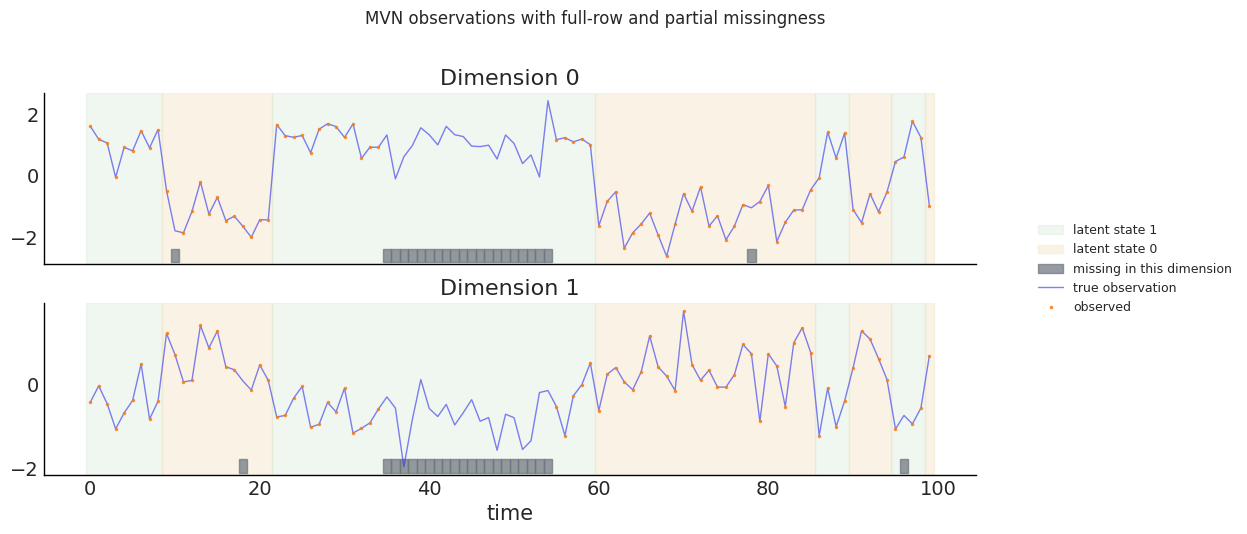

In [3]:
MVN_MEANS = jnp.array([[-1.2, 0.6], [1.1, -0.7]])
MVN_COV = jnp.array([[0.30, 0.14], [0.14, 0.28]])


def mvn_observation_model(x, u, t):
    return dist.MultivariateNormal(MVN_MEANS[x], covariance_matrix=MVN_COV)


mvn_hmm = make_hmm_model(mvn_observation_model)

states_true_mvn, obs_true_mvn = simulate_hmm_dataset(mvn_hmm, key=DATA_KEY_MVN)
obs_missing_mvn = apply_full_and_partial_missing(
    obs_true_mvn,
    full_slice=slice(35, 55),
    partial_locs=[(10, 0), (18, 1), (78, 0), (96, 1)],
)

plot_continuous_observations(
    OBS_TIMES,
    states_true_mvn,
    np.asarray(obs_true_mvn),
    np.asarray(obs_missing_mvn),
    "MVN observations with full-row and partial missingness",
)


True A:
 [[0.92 0.08]
 [0.12 0.88]]
Posterior mean A:
 [[0.90047952 0.09952048]
 [0.12703662 0.87296338]]


/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_15808/309256623.py:92: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


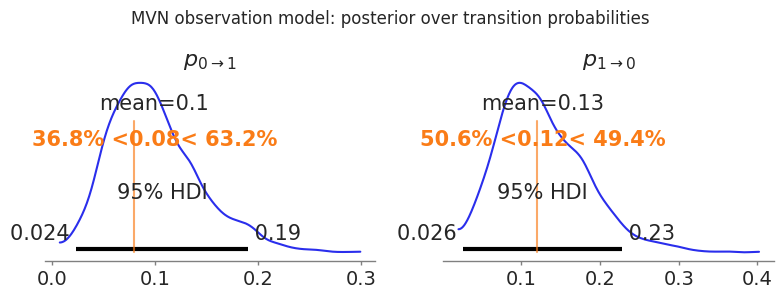

/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_15808/309256623.py:248: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 0.84, 1))


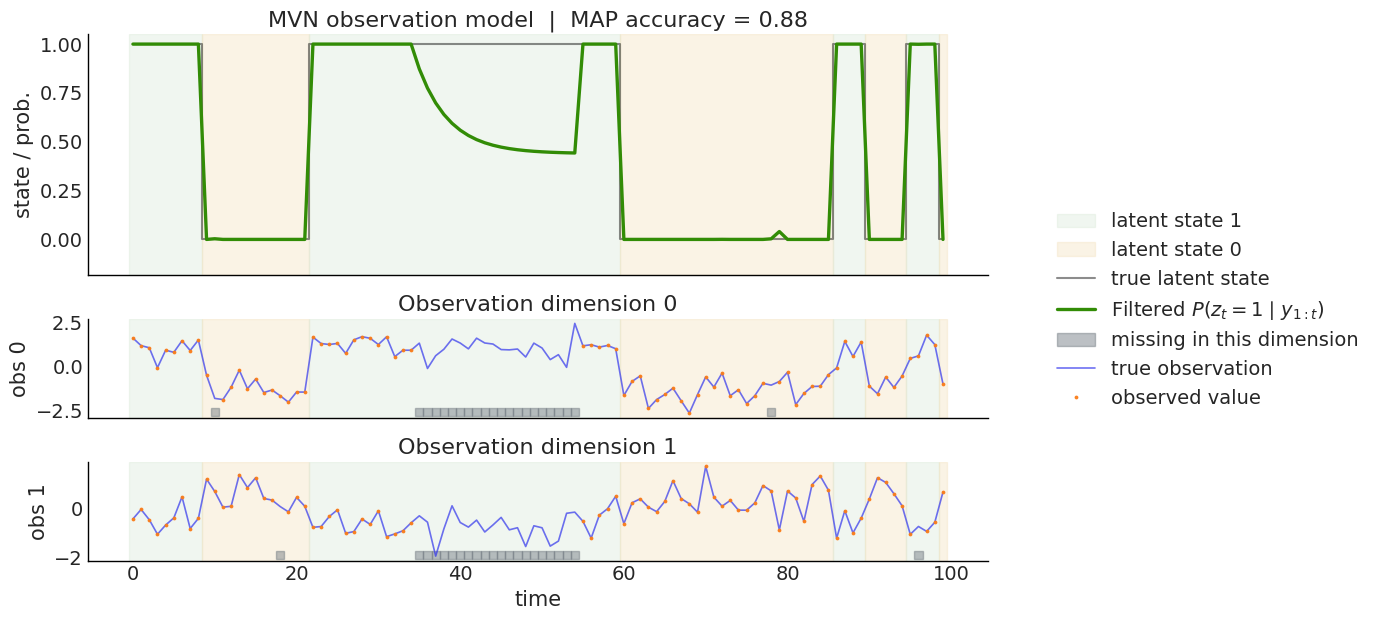

In [4]:
posterior_mvn, A_post_mean_mvn, filtered_mvn = infer_hmm(
    mvn_hmm,
    OBS_TIMES,
    obs_missing_mvn,
    fit_key=FIT_KEY_MVN,
    recon_key=RECON_KEY_MVN,
)

print("True A:\n", TRUE_A)
print("Posterior mean A:\n", A_post_mean_mvn)
plot_transition_posterior(posterior_mvn, TRUE_A, "MVN observation model: posterior over transition probabilities")
plot_latent_reconstruction(
    OBS_TIMES,
    states_true_mvn,
    filtered_mvn,
    np.asarray(obs_true_mvn),
    np.asarray(obs_missing_mvn),
    "MVN observation model",
    observation_kind="continuous",
)


## 3. Example 2: two independent categorical observations

Next we switch to two **independent binary categorical sensors**.

Concretely, conditional on the latent state $z_t$, the two sensors are independent 2-class categorical observations with probabilities

$$
z_t = 0: \quad y_t^{(1)} \sim \mathrm{Categorical}(0.85, 0.15), \qquad y_t^{(2)} \sim \mathrm{Categorical}(0.70, 0.30),
$$

$$
z_t = 1: \quad y_t^{(1)} \sim \mathrm{Categorical}(0.20, 0.80), \qquad y_t^{(2)} \sim \mathrm{Categorical}(0.35, 0.65).
$$

So the full observation model is

$$
p(y_t \mid z_t) = p(y_t^{(1)} \mid z_t)\, p(y_t^{(2)} \mid z_t).
$$

This is exactly the `Independent(..., 1)` case, so partial missingness is still easy: we just sum the observed coordinate log-probabilities and skip the missing ones.


/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_15808/309256623.py:303: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 0.83, 0.96))


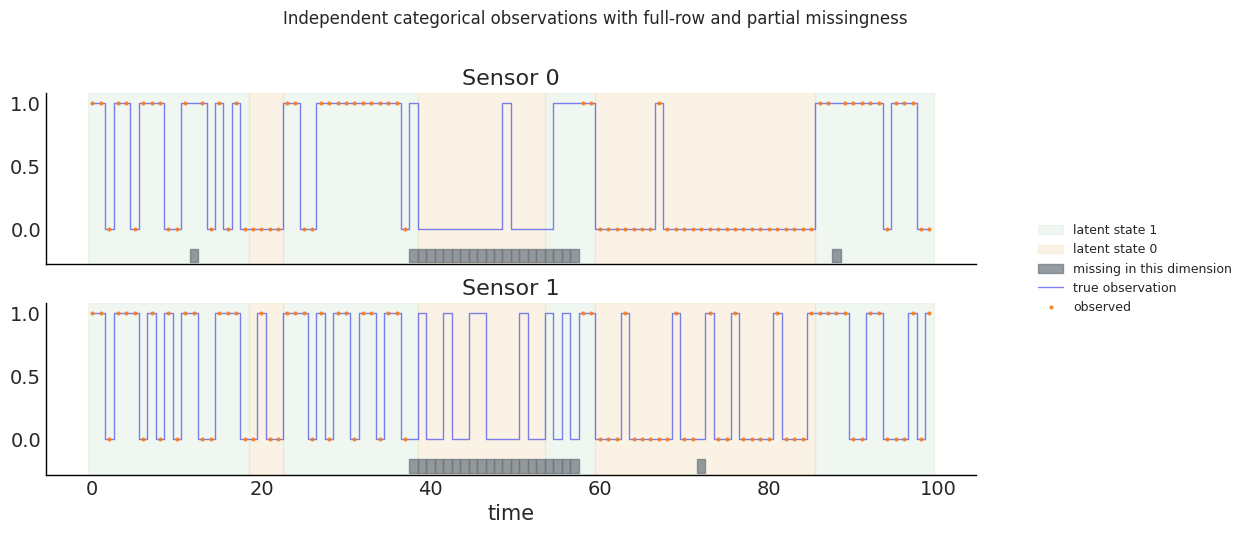

In [5]:
INDEPENDENT_CAT_PROBS = jnp.array(
    [
        [[0.85, 0.15], [0.70, 0.30]],
        [[0.20, 0.80], [0.35, 0.65]],
    ]
)


def independent_categorical_observation_model(x, u, t):
    return dist.Independent(dist.Categorical(probs=INDEPENDENT_CAT_PROBS[x]), 1)


independent_cat_hmm = make_hmm_model(independent_categorical_observation_model)

states_true_cat, obs_true_cat = simulate_hmm_dataset(independent_cat_hmm, key=DATA_KEY_CAT)
obs_missing_cat = apply_full_and_partial_missing(
    obs_true_cat.astype(float),
    full_slice=slice(38, 58),
    partial_locs=[(12, 0), (72, 1), (88, 0)],
)

plot_binary_observations(
    OBS_TIMES,
    states_true_cat,
    np.asarray(obs_true_cat),
    np.asarray(obs_missing_cat),
    "Independent categorical observations with full-row and partial missingness",
)


True A:
 [[0.92 0.08]
 [0.12 0.88]]
Posterior mean A:
 [[0.84302368 0.15697632]
 [0.14531677 0.85468323]]


/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_15808/309256623.py:92: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


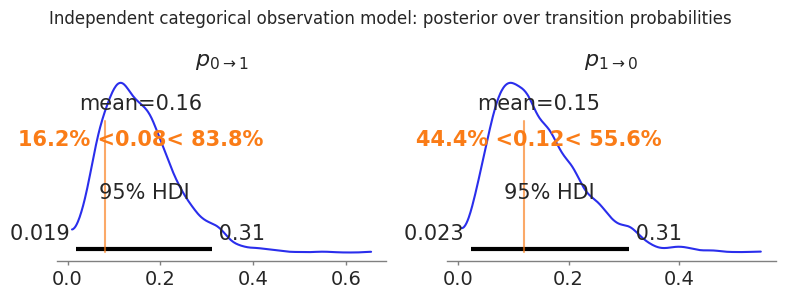

/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_15808/309256623.py:248: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 0.84, 1))


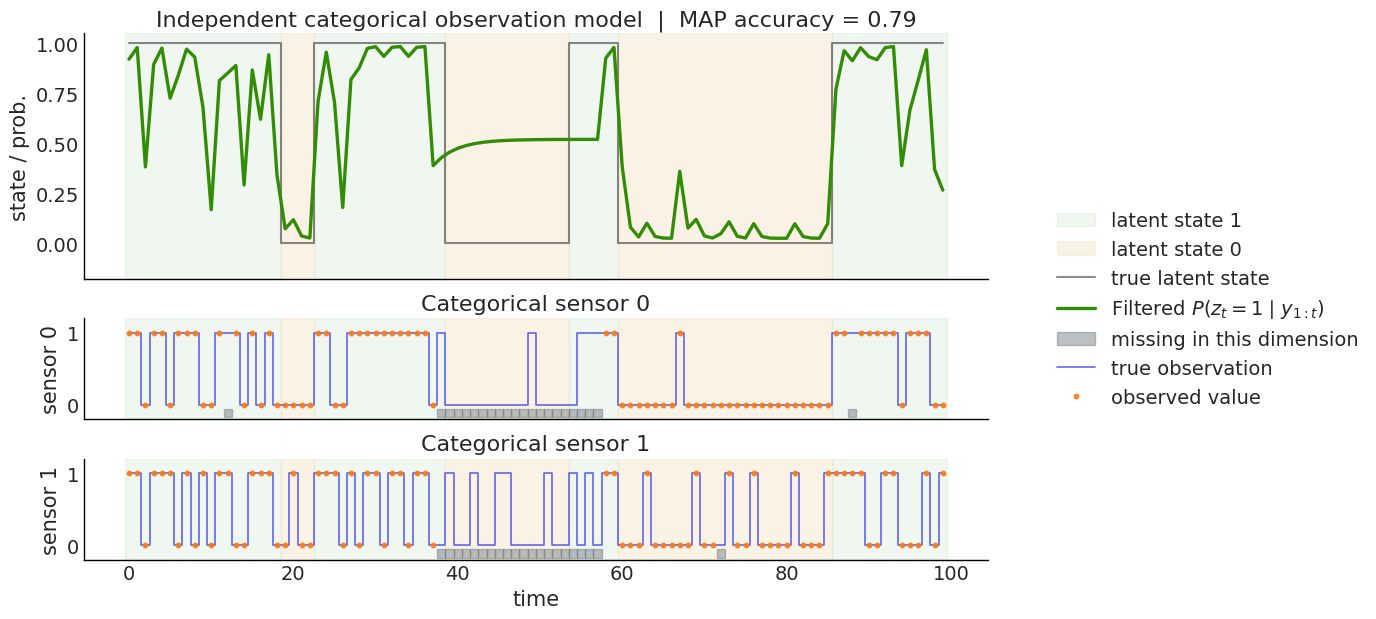

In [6]:
posterior_cat, A_post_mean_cat, filtered_cat = infer_hmm(
    independent_cat_hmm,
    OBS_TIMES,
    obs_missing_cat,
    fit_key=FIT_KEY_CAT,
    recon_key=RECON_KEY_CAT,
)

print("True A:\n", TRUE_A)
print("Posterior mean A:\n", A_post_mean_cat)
plot_transition_posterior(posterior_cat, TRUE_A, "Independent categorical observation model: posterior over transition probabilities")
plot_latent_reconstruction(
    OBS_TIMES,
    states_true_cat,
    filtered_cat,
    np.asarray(obs_true_cat),
    np.asarray(obs_missing_cat),
    "Independent categorical observation model",
    observation_kind="categorical",
)


## 4. How You Could Extend This Tutorial

A natural next example would be a **correlated categorical pair**.

The clean semantic representation for that data is usually a two-coordinate observation at each time step, not two conditionally independent categorical sensors. The challenge is that, once the coordinates are correlated, partial missingness is no longer handled automatically by the built-in `Independent(..., 1)` path.

So an advanced Example 3 would require one of two things:

1. a custom joint discrete observation distribution on a vector-valued observation, together with custom logic for marginalizing missing coordinates, or
2. a different exact representation of the correlated pair that still exposes the right marginals to the missingness machinery.

That is a useful direction, but it is no longer a minimal tutorial about the core built-in HMM missingness features in `dynestyx`, so we stop here.


## 5. Summary

For HMMs, missingness support is all about the **observation family**:

- **`MultivariateNormal`** supports both full-row and partial missingness because we can compute exact Gaussian marginals over observed coordinates.
- **`Independent(..., 1)`** supports both full-row and partial missingness because coordinate log-probabilities add.
- **Correlated joint discrete families** are a natural extension point, but they are not part of this introductory tutorial because they require extra modeling work beyond the built-in paths above.

The latent-state recursion itself never changed across these examples. What changed was only the quantity we fed into the forward algorithm:

$$
\log p(y_t \mid z_t)
\quad \longrightarrow \quad
\log p(y_{t,\mathrm{obs}} \mid z_t).
$$

That is the right mental model for HMM missingness in `dynestyx`.


**Previous:** [Part 11b — Missing observations with `LatentStateBuilder` + MCMC](../11b_missing_observations_latent_state_builder_mcmc/)

**Next:** [Part 12 — Hierarchical modeling patterns](../12_hierarchical_modeling_patterns/)
